# 4. Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?

# 4.1 Evaluation metrics: session overview

- Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
- https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv

*Metric* - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [1106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [1107]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [1108]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv -O data-week-3.csv

In [1109]:
df = pd.read_csv('data/data-week-3.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [1110]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [1111]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [1112]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

/Users/alexandru.huc/Downloads/Development/GitHub/learning-repo/ZoomCamp/machine-learning-zoomcamp-2025/mle_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [1113]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

# 4.2 Accuracy and dummy model

- Evaluate the model on different thresholds
- Check the accuracy of dummy baselines

In [1114]:
len(y_val)

1409

In [1115]:
(y_val == churn_decision).sum()

np.int64(1132)

In [1116]:
1132/1409

0.8034066713981547

In [1117]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.666
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


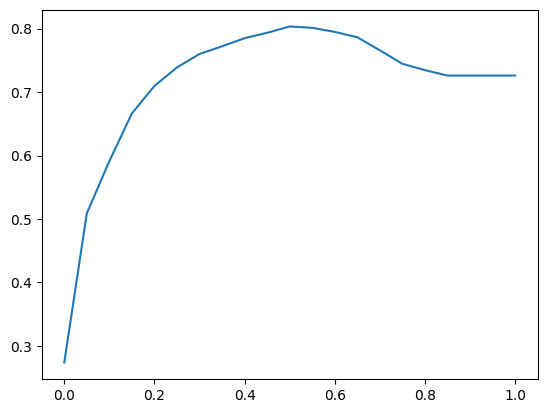

In [1118]:
plt.plot(thresholds, scores)

In [1119]:
# Another method is to use the accuracy_score from skleran
from sklearn.metrics import accuracy_score

In [1120]:
accuracy_score(y_val, y_pred >= 5)

0.7260468417317246

In [1121]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= 5)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.726
0.05 0.726
0.10 0.726
0.15 0.726
0.20 0.726
0.25 0.726
0.30 0.726
0.35 0.726
0.40 0.726
0.45 0.726
0.50 0.726
0.55 0.726
0.60 0.726
0.65 0.726
0.70 0.726
0.75 0.726
0.80 0.726
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


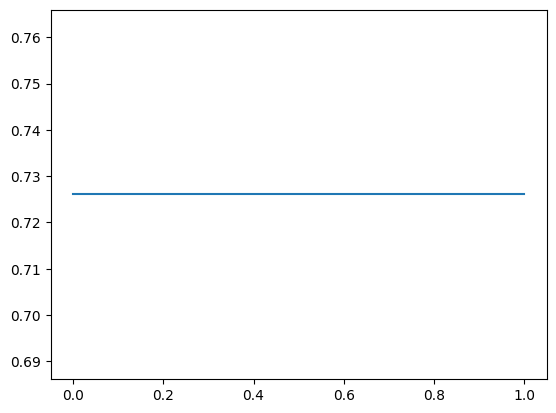

In [1122]:
plt.plot(thresholds, scores)

In [1123]:
from collections import Counter

In [1124]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [1125]:
1 - y_val.mean()

np.float64(0.7260468417317246)

# 4.3 Confusion table
- Different types of errors and correct decisions
- Arranging them in a table

In [1126]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [1127]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [1128]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

tp, tn, fp, fn

(np.int64(210), np.int64(922), np.int64(101), np.int64(176))

In [1129]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[922, 101],
       [176, 210]])

In [1130]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

# 4.4 Precision and Recall

In [1131]:
(tp + tn) / (tp + tn + fp + fn)

np.float64(0.8034066713981547)

In [1132]:
# PRECISION
p = tp / (tp + fp)
p

np.float64(0.6752411575562701)

In [1133]:
tp

np.int64(210)

In [1134]:
(tp + fp)

np.int64(311)

In [1135]:
# RECALL
r = tp / (tp + fn)
r

np.float64(0.5440414507772021)

In [1136]:
(tp + fn)

np.int64(386)

# 4.5 ROC Curves

## TRP and FRP

In [1137]:
# True Positive Rate
tpr = tp / (tp + fn)
tpr

np.float64(0.5440414507772021)

In [1138]:
# False Positive Rate
fpr = fp / (fp + tn)
fpr

np.float64(0.09872922776148582)

In [1139]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, fn, tn))

In [1140]:
columns = ['thresholds', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

In [1141]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [1142]:
df_scores[::10]

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,556,20,467,0.948187,0.543500
20,0.2,333,356,53,667,0.862694,0.347996
30,0.3,284,236,102,787,0.735751,0.230694
40,0.4,249,166,137,857,0.645078,0.162268
50,0.5,210,101,176,922,0.544041,0.098729
60,0.6,150,53,236,970,0.388601,0.051808
70,0.7,76,20,310,1003,0.196891,0.019550
80,0.8,13,1,373,1022,0.033679,0.000978
90,0.9,0,0,386,1023,0.000000,0.000000


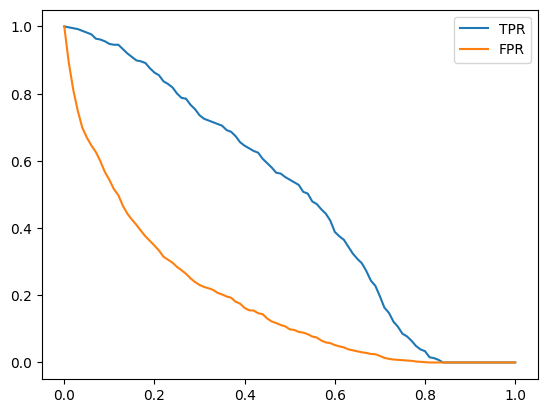

In [1143]:
plt.plot(df_scores.thresholds, df_scores.tpr, label='TPR')
plt.plot(df_scores.thresholds, df_scores.fpr, label='FPR')
plt.legend()

## Random model

In [1144]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [1145]:
y_rand.round(3)

array([0.417, 0.72 , 0.   , ..., 0.774, 0.334, 0.089], shape=(1409,))

In [1146]:
((y_rand >= 0.5) ==y_val).mean()

np.float64(0.5017743080198722)

In [1147]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['thresholds', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [1148]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [1149]:
df_rand

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,382,1013,4,10,0.989637,0.990225
2,0.02,379,993,7,30,0.981865,0.970674
3,0.03,375,979,11,44,0.971503,0.956989
4,0.04,372,969,14,54,0.963731,0.947214
...,...,...,...,...,...,...,...
96,0.96,14,41,372,982,0.036269,0.040078
97,0.97,11,36,375,987,0.028497,0.035191
98,0.98,8,19,378,1004,0.020725,0.018573
99,0.99,6,7,380,1016,0.015544,0.006843


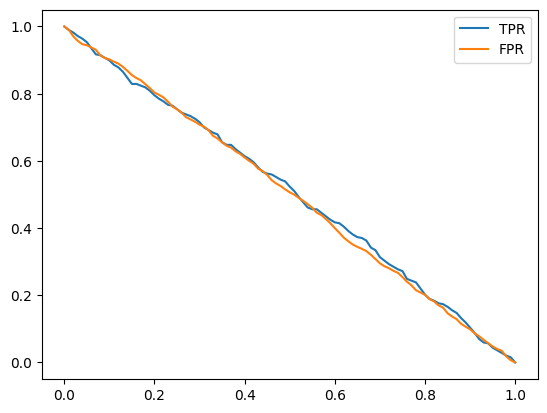

In [1150]:
plt.plot(df_rand.thresholds, df_rand.tpr, label='TPR')
plt.plot(df_rand.thresholds, df_rand.fpr, label='FPR')
plt.legend()

## Ideal model

In [1151]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [1152]:
y_idea = np.repeat([0, 1], [num_neg, num_pos])
y_idea

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [1153]:
y_idea_pred = np.linspace(0, 1, len(y_val))
y_idea_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00], shape=(1409,))

In [1154]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [1155]:
((y_idea_pred >= 0.726) == y_idea).mean()

np.float64(1.0)

In [1156]:
df_ideal = tpr_fpr_dataframe(y_idea, y_idea_pred)

In [1157]:
df_ideal[::10]

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


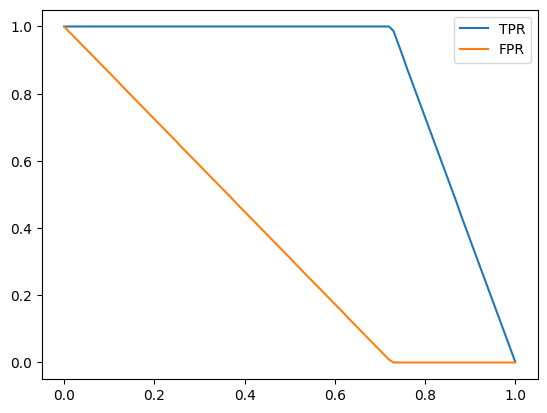

In [1158]:
plt.plot(df_ideal.thresholds, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.thresholds, df_ideal.fpr, label='FPR')
plt.legend()

# Putting everything together

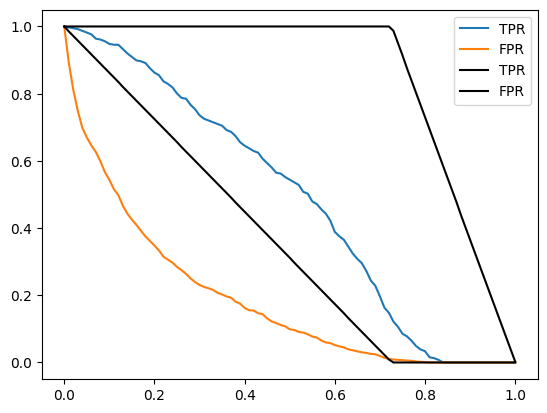

In [1159]:
plt.plot(df_scores.thresholds, df_scores.tpr, label='TPR')
plt.plot(df_scores.thresholds, df_scores.fpr, label='FPR')

# plt.plot(df_rand.thresholds, df_rand.tpr, label='TPR')
# plt.plot(df_rand.thresholds, df_rand.fpr, label='FPR')

plt.plot(df_ideal.thresholds, df_ideal.tpr, label='TPR', color='black')
plt.plot(df_ideal.thresholds, df_ideal.fpr, label='FPR', color='black')

plt.legend()

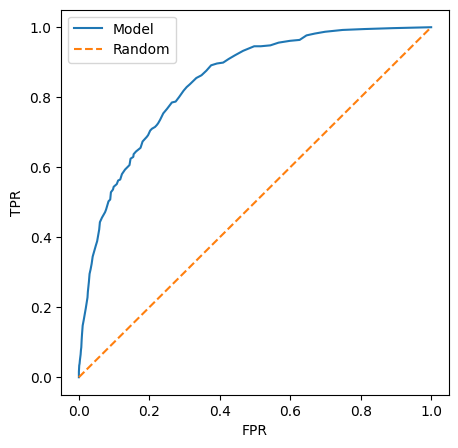

In [1160]:
plt.figure(figsize=(5,5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
# plt.plot(df_rand.fpr, df_rand.tpr, label='random')
# plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [1161]:
from sklearn.metrics import roc_curve

In [1162]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

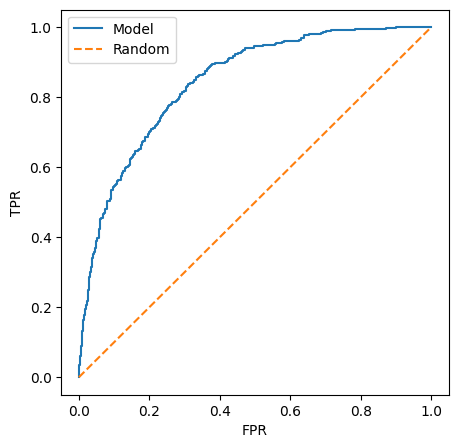

In [1163]:
plt.figure(figsize=(5,5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

# 4.6 ROC AUC

- Area under the ROC curve - useful metric
- Interpretation of AUC

In [1164]:
from sklearn.metrics import auc

In [1165]:
auc(fpr, tpr)

0.8438150517374986

In [1166]:
auc(df_scores.fpr, df_scores.tpr)

0.8438872259280081

In [1167]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [1168]:
auc(df_rand.fpr, df_rand.tpr)

0.5060233793728696

In [1169]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.8438150517374986

In [1170]:
from sklearn.metrics import roc_auc_score

In [1171]:
roc_auc_score(y_val, y_pred)

0.8438150517374986

In [1172]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [1173]:
neg

array([0.00900637, 0.20481179, 0.21249479, ..., 0.10778811, 0.31388198,
       0.13649881], shape=(1023,))

In [1174]:
pos

array([0.54307202, 0.58247189, 0.46175862, 0.73945734, 0.06581722,
       0.69169194, 0.24744064, 0.69656679, 0.21235897, 0.66508228,
       0.47358029, 0.34877568, 0.15046407, 0.6176401 , 0.76472765,
       0.14255839, 0.43288885, 0.27299728, 0.06895289, 0.19227657,
       0.67070445, 0.41589736, 0.66204383, 0.58327799, 0.52445213,
       0.43314854, 0.46874916, 0.35142565, 0.56768937, 0.3218819 ,
       0.63525718, 0.74366422, 0.73843995, 0.60888285, 0.70874262,
       0.76477687, 0.10738953, 0.18081815, 0.54228646, 0.57943021,
       0.4366188 , 0.44064507, 0.75706363, 0.38569019, 0.69440133,
       0.41755883, 0.75787727, 0.30225805, 0.53387615, 0.58076826,
       0.15403469, 0.52943857, 0.78576788, 0.43666887, 0.67323442,
       0.77441154, 0.01265248, 0.35119147, 0.79768366, 0.5846067 ,
       0.67391091, 0.24831443, 0.34500442, 0.70162802, 0.20960448,
       0.68594691, 0.63632464, 0.2910986 , 0.66049684, 0.30806415,
       0.50182876, 0.27205501, 0.3970608 , 0.41046581, 0.49925

In [1175]:
import random

In [1176]:
n = 100000
success = 0

for i in range(n):
    pos_index = random.randint(0, len(pos) - 1)
    neg_index = random.randint(0, len(neg) - 1)

    if pos[pos_index] > neg[neg_index]:
        success = success + 1

success/n

0.84221

In [1177]:
n = 10000
pos_index = np.random.randint(0, len(pos), size=n)
neg_index = np.random.randint(0, len(neg), size=n)

In [1178]:
n = 50000

np.random.seed(1)
pos_index = np.random.randint(0, len(pos), size=n)
neg_index = np.random.randint(0, len(neg), size=n)

(pos[pos_index] > neg[neg_index]).mean()

np.float64(0.84646)

# 4.7 Cross-Validation

- Evaluating the same model on different subsets of data
- Getting the average prediction and the spread within predictions

In [1189]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=10000)
    model.fit(X_train, y_train)

    return dv, model

In [1190]:
dv, model = train(df_train, y_train, C=0.001)

In [1181]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [1182]:
y_pred = predict(df_val, dv, model)
y_pred

array([0.02499789, 0.23988605, 0.2463555 , ..., 0.24683148, 0.75555707,
       0.75890482], shape=(1409,))

In [1183]:
from sklearn.model_selection import KFold

In [1184]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [1185]:
# !pip install tqdm
from tqdm.auto import tqdm

In [1191]:
n_splits = 5
for C in [0.001, 0.01, 0.1, 0.5, 1, 5, 10]:
    scores = []

    kfold = KFold(n_splits=10, shuffle=True, random_state=1)

    for train_idx, val_idx in tqdm(kfold.split(df_full_train), total=n_splits):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn
        y_val = df_val.churn

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

10it [00:01,  5.88it/s]                      


C=0.001 0.826 +- 0.012


10it [00:03,  2.62it/s]                      


C=0.01 0.841 +- 0.012


10it [00:08,  1.13it/s]                      


C=0.1 0.842 +- 0.012


10it [00:04,  2.40it/s]                      


C=0.5 0.843 +- 0.012


10it [00:05,  1.93it/s]                      


C=1 0.843 +- 0.012


10it [00:05,  1.74it/s]                      


C=5 0.842 +- 0.012


10it [00:06,  1.62it/s]                      

C=10 0.842 +- 0.012


In [1194]:
scores

[0.8501502790897382,
 0.8412902227722772,
 0.8585120342840057,
 0.8328944119825529,
 0.824968982630273,
 0.8411421911421912,
 0.8430478671442527,
 0.8254506641366224,
 0.8458129539054395,
 0.8604920842996874]

In [1193]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_val, dv, model)

auc = roc_auc_score(y_val, y_pred)
auc

0.8663574333635845

# 4.8 Summary
- Metric - a single number that describes the performance of a model
- Accuracy - fraction of correct answers; sometimes misleading
- Precision and recall are less misleading when we have class inbalance
- ROC Curve - a way to evaluate the performance at all thresholds; okay to use with imbalance
- K-Fold CV - more reliable estimate for performance (mean + std)

# 4.9 Explore more
- Check the precision and recall of the dummy classifier that always predict "FALSE"
- F1 score = 2 * P * R / (P + R)
- Evaluate precision and recall at different thresholds, plot P vs R - this way you'll get the precision/recall curve (similar to ROC curve)
- Area under the PR curve is also a useful metric

Other projects:
- Calculate the metrics for datasets from the previous week